In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker

# Load data

In [2]:
# number of jobs
job_number = 100

# number of rounds of X stabilizer
rounds_list = range(1,11)
# number of preselected rounds
preselect_list = range(0,4)

# Save logical error
Logical_Error = np.full((len(preselect_list),len(rounds_list)),np.nan)
# Save logical error uncertainty
Logical_Error_u = np.full((len(preselect_list),len(rounds_list)),np.nan)

# loop through preselected rounds
for preselect in preselect_list:
    # loop through number of rounds
    for index_rounds, rounds in enumerate(rounds_list): 
        nb_accepted = 0
        nb_fail = 0

        # loop through jobs
        for index in range(job_number):
            result = json.load(open(f'Results/result_{rounds}_{index}.json', 'r'))

            if preselect < len(result['preselected&accepted&fail']):
                nb_fail += result['preselected&accepted&fail'][preselect]
                nb_accepted += result['preselected&accepted'][preselect]

        if nb_accepted != 0:
            Logical_Error[preselect,index_rounds] = nb_fail/nb_accepted
            Logical_Error_u[preselect,index_rounds] = 1.96*np.sqrt(nb_fail/nb_accepted**2)

# Plot logical error rate

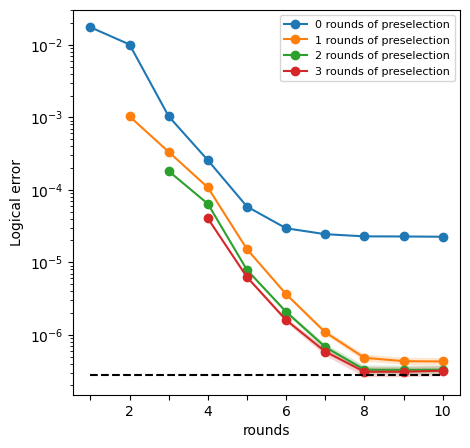

In [7]:
plt.figure(figsize=(5,5))         

# loop through preselected rounds
for preselect in preselect_list:
    # logical error
    plt.plot(rounds_list,Logical_Error[preselect],'-o',label = f'{preselect} rounds of preselection')
    # error bar
    plt.fill_between(rounds_list,Logical_Error[preselect] - Logical_Error_u[preselect],
                     Logical_Error[preselect] + Logical_Error_u[preselect], alpha=0.2)
    
# theoritcal 35p^3 of distillation
plt.plot([rounds_list[0],rounds_list[-1]],[35*(2/3*1e-3 + 1e-3 + 1e-3/3)**3]*2,'--',c='k')

# x tick and label
ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.NullLocator())       
tick_positions = range(rounds_list[0], rounds_list[-1] + 1)
tick_labels = [str(x) if x % 2 == 0 else '' for x in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)

plt.legend(loc = 'upper right',fontsize = 8)
plt.yscale('log')
plt.xlabel('rounds')
plt.ylabel('Logical error')
plt.show()